In [152]:
from pathlib import Path
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%config InlineBackend.figure_format = 'retina'

out_csv = Path('../results/tables')
out_csv.mkdir(parents=True, exist_ok=True)

In [153]:
artem_results_with_old_jnd = pd.DataFrame([
    dict(model='jnd_kkk', approach='white-box', eps='2/255',  clean=0.860, robust=0.092, ASR=0.893, L2=1.150, Linf=0.0078, jnd_L2=203.0,  jnd_Linf=3.33),
    dict(model='jnd_kkk', approach='transfer',  eps='2/255',  clean=0.860, robust=0.695, ASR=0.193, L2=1.153, Linf=0.0078, jnd_L2=194.2,  jnd_Linf=3.31),
    dict(model='mine',    approach='white-box', eps='2/255',  clean=0.884, robust=0.552, ASR=0.376, L2=1.086, Linf=0.0078, jnd_L2=188.9,  jnd_Linf=3.30),
    dict(model='mine',    approach='transfer',  eps='2/255',  clean=0.880, robust=0.826, ASR=0.067, L2=1.153, Linf=0.0078, jnd_L2=194.2,  jnd_Linf=3.31),
    dict(model='jnd_kkk', approach='white-box', eps='4/255',  clean=0.860, robust=0.001, ASR=0.999, L2=2.207, Linf=0.0157, jnd_L2=359.8,  jnd_Linf=6.07),
    dict(model='jnd_kkk', approach='transfer',  eps='4/255',  clean=0.860, robust=0.487, ASR=0.436, L2=2.190, Linf=0.0157, jnd_L2=343.1,  jnd_Linf=6.04),
    dict(model='mine',    approach='white-box', eps='4/255',  clean=0.884, robust=0.225, ASR=0.745, L2=2.195, Linf=0.0157, jnd_L2=351.7,  jnd_Linf=6.05),
    dict(model='mine',    approach='transfer',  eps='4/255',  clean=0.884, robust=0.752, ASR=0.155, L2=2.191, Linf=0.0157, jnd_L2=343.2,  jnd_Linf=6.03),
    dict(model='jnd_kkk', approach='white-box', eps='8/255',  clean=0.860, robust=0.000, ASR=1.000, L2=4.155, Linf=0.0314, jnd_L2=632.7,  jnd_Linf=10.88),
    dict(model='jnd_kkk', approach='transfer',  eps='8/255',  clean=0.860, robust=0.223, ASR=0.741, L2=4.043, Linf=0.0314, jnd_L2=602.3,  jnd_Linf=10.82),
    dict(model='mine',    approach='white-box', eps='8/255',  clean=0.877, robust=0.016, ASR=0.982, L2=4.373, Linf=0.0314, jnd_L2=668.2,  jnd_Linf=10.97),
    dict(model='mine',    approach='transfer',  eps='8/255',  clean=0.884, robust=0.599, ASR=0.324, L2=4.045, Linf=0.0314, jnd_L2=602.4,  jnd_Linf=10.83),
    dict(model='jnd_kkk', approach='white-box', eps='16/255', clean=0.860, robust=0.000, ASR=1.000, L2=7.662, Linf=0.0627, jnd_L2=1079.9, jnd_Linf=19.37),
    dict(model='jnd_kkk', approach='transfer',  eps='16/255', clean=0.860, robust=0.049, ASR=0.943, L2=7.300, Linf=0.0627, jnd_L2=1028.0, jnd_Linf=19.25),
    dict(model='mine',    approach='white-box', eps='16/255', clean=0.882, robust=0.000, ASR=1.000, L2=8.383, Linf=0.0627, jnd_L2=1225.4, jnd_Linf=19.67),
    dict(model='mine',    approach='transfer',  eps='16/255', clean=0.887, robust=0.304, ASR=0.657, L2=7.301, Linf=0.0627, jnd_L2=1027.7, jnd_Linf=19.25),
])

In [154]:
artem_results_with_old_jnd

,model,approach,eps,clean,robust,ASR,L2,Linf,jnd_L2,jnd_Linf
0,jnd_kkk,white-box,2/255,0.860,0.092,0.893,1.150,0.0078,203.0,3.33
1,jnd_kkk,transfer,2/255,0.860,0.695,0.193,1.153,0.0078,194.2,3.31
2,mine,white-box,2/255,0.884,0.552,0.376,1.086,0.0078,188.9,3.30
3,mine,transfer,2/255,0.880,0.826,0.067,1.153,0.0078,194.2,3.31
4,jnd_kkk,white-box,4/255,0.860,0.001,0.999,2.207,0.0157,359.8,6.07
5,jnd_kkk,transfer,4/255,0.860,0.487,0.436,2.190,0.0157,343.1,6.04
6,mine,white-box,4/255,0.884,0.225,0.745,2.195,0.0157,351.7,6.05
7,mine,transfer,4/255,0.884,0.752,0.155,2.191,0.0157,343.2,6.03
8,jnd_kkk,white-box,8/255,0.860,0.000,1.000,4.155,0.0314,632.7,10.88
9,jnd_kkk,transfer,8/255,0.860,0.223,0.741,4.043,0.0314,602.3,10.82


In [155]:
artem_results = pd.DataFrame([
    #dict(model='jnd_kkk', approach='white-box', eps='2/255',  clean=0.860, robust=0.092, ASR=0.893, L2=1.150, Linf=0.0078, jnd_L2=203.0,  jnd_Linf=3.33),
    #dict(model='jnd_kkk', approach='transfer',  eps='2/255',  clean=0.860, robust=0.695, ASR=0.193, L2=1.153, Linf=0.0078, jnd_L2=194.2,  jnd_Linf=3.31),
    dict(model='mine',    approach='white-box', eps='2/255',  clean=0.884, robust=0.552, ASR=0.376, L2=1.086, Linf=0.0078, jnd_L2=188.9,  jnd_Linf=3.30),
    dict(model='mine',    approach='transfer',  eps='2/255',  clean=0.880, robust=0.826, ASR=0.067, L2=1.153, Linf=0.0078, jnd_L2=194.2,  jnd_Linf=3.31),
    #dict(model='jnd_kkk', approach='white-box', eps='4/255',  clean=0.860, robust=0.001, ASR=0.999, L2=2.207, Linf=0.0157, jnd_L2=359.8,  jnd_Linf=6.07),
    #dict(model='jnd_kkk', approach='transfer',  eps='4/255',  clean=0.860, robust=0.487, ASR=0.436, L2=2.190, Linf=0.0157, jnd_L2=343.1,  jnd_Linf=6.04),
    dict(model='mine',    approach='white-box', eps='4/255',  clean=0.884, robust=0.225, ASR=0.745, L2=2.195, Linf=0.0157, jnd_L2=351.7,  jnd_Linf=6.05),
    dict(model='mine',    approach='transfer',  eps='4/255',  clean=0.884, robust=0.752, ASR=0.155, L2=2.191, Linf=0.0157, jnd_L2=343.2,  jnd_Linf=6.03),
    #dict(model='jnd_kkk', approach='white-box', eps='8/255',  clean=0.860, robust=0.000, ASR=1.000, L2=4.155, Linf=0.0314, jnd_L2=632.7,  jnd_Linf=10.88),
    #dict(model='jnd_kkk', approach='transfer',  eps='8/255',  clean=0.860, robust=0.223, ASR=0.741, L2=4.043, Linf=0.0314, jnd_L2=602.3,  jnd_Linf=10.82),
    dict(model='mine',    approach='white-box', eps='8/255',  clean=0.877, robust=0.016, ASR=0.982, L2=4.373, Linf=0.0314, jnd_L2=668.2,  jnd_Linf=10.97),
    dict(model='mine',    approach='transfer',  eps='8/255',  clean=0.884, robust=0.599, ASR=0.324, L2=4.045, Linf=0.0314, jnd_L2=602.4,  jnd_Linf=10.83),
    #dict(model='jnd_kkk', approach='white-box', eps='16/255', clean=0.860, robust=0.000, ASR=1.000, L2=7.662, Linf=0.0627, jnd_L2=1079.9, jnd_Linf=19.37),
    #dict(model='jnd_kkk', approach='transfer',  eps='16/255', clean=0.860, robust=0.049, ASR=0.943, L2=7.300, Linf=0.0627, jnd_L2=1028.0, jnd_Linf=19.25),
    dict(model='mine',    approach='white-box', eps='16/255', clean=0.882, robust=0.000, ASR=1.000, L2=8.383, Linf=0.0627, jnd_L2=1225.4, jnd_Linf=19.67),
    dict(model='mine',    approach='transfer',  eps='16/255', clean=0.887, robust=0.304, ASR=0.657, L2=7.301, Linf=0.0627, jnd_L2=1027.7, jnd_Linf=19.25),
])

In [156]:
artem_results

,model,approach,eps,clean,robust,ASR,L2,Linf,jnd_L2,jnd_Linf
0,mine,white-box,2/255,0.884,0.552,0.376,1.086,0.0078,188.9,3.30
1,mine,transfer,2/255,0.880,0.826,0.067,1.153,0.0078,194.2,3.31
2,mine,white-box,4/255,0.884,0.225,0.745,2.195,0.0157,351.7,6.05
3,mine,transfer,4/255,0.884,0.752,0.155,2.191,0.0157,343.2,6.03
4,mine,white-box,8/255,0.877,0.016,0.982,4.373,0.0314,668.2,10.97
5,mine,transfer,8/255,0.884,0.599,0.324,4.045,0.0314,602.4,10.83
6,mine,white-box,16/255,0.882,0.000,1.000,8.383,0.0627,1225.4,19.67
7,mine,transfer,16/255,0.887,0.304,0.657,7.301,0.0627,1027.7,19.25


In [157]:
RESULTS_PATH = Path('../results/attack_results.json')

with open(RESULTS_PATH, 'r', encoding='utf-8') as file:
    raw_results = json.load(file)

In [158]:
rows = []

for eps, models in raw_results.get('transfer', {}).items():
    for model_name, m in models.items():
        l2_mean = np.mean(m['norms_rgb']['l2'])
        linf_mean = np.mean(m['norms_rgb']['linf'])
        
        if 'norms_target' in m and m['norms_target']['l2']:
            jnd_l2_mean = np.mean(m['norms_target']['l2'])
            jnd_linf_mean = np.mean(m['norms_target']['linf'])
        else:
            jnd_l2_mean = None
            jnd_linf_mean = None

        rows.append({
            'model': model_name,
            'approach': 'transfer',
            'eps': eps,
            'clean': round(m['clean_acc'], 3),
            'robust': round(m['robust_acc'], 3),
            'ASR': round(m['asr'], 3),
            'L2': round(float(l2_mean), 3),
            'Linf': round(float(linf_mean), 4),
            'jnd_L2': round(float(jnd_l2_mean), 1) if jnd_l2_mean is not None else np.nan,
            'jnd_Linf': round(float(jnd_linf_mean), 2) if jnd_linf_mean is not None else np.nan
        })

for model_name, eps_dict in raw_results.get('bpda', {}).items():
    for eps, m in eps_dict.items():
        l2_mean = np.mean(m['norms_rgb']['l2'])
        linf_mean = np.mean(m['norms_rgb']['linf'])
        
        if 'norms_target' in m and m['norms_target']['l2']:
            jnd_l2_mean = np.mean(m['norms_target']['l2'])
            jnd_linf_mean = np.mean(m['norms_target']['linf'])
        else:
            jnd_l2_mean = None
            jnd_linf_mean = None

        rows.append({
            'model': model_name,
            'approach': 'white-box',
            'eps': eps,
            'clean': round(m['clean_acc'], 3),
            'robust': round(m['robust_acc'], 3),
            'ASR': round(m['asr'], 3),
            'L2': round(float(l2_mean), 3),
            'Linf': round(float(linf_mean), 4),
            'jnd_L2': round(float(jnd_l2_mean), 1) if jnd_l2_mean is not None else np.nan,
            'jnd_Linf': round(float(jnd_linf_mean), 2) if jnd_linf_mean is not None else np.nan
        })

In [159]:
my_results = pd.DataFrame(rows)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(my_results)

my_results.to_csv(out_csv / 'Jnd_results.csv', index=False, encoding='utf-8')

,model,approach,eps,clean,robust,ASR,L2,Linf,jnd_L2,jnd_Linf
0,model_rgb,transfer,2/255,0.9,0.3,0.667,1.155,0.0078,NaN,NaN
1,model_kkk_None,transfer,2/255,1.0,0.9,0.100,1.155,0.0078,45.1,1.0
2,model_kkk_4cm,transfer,2/255,0.8,0.7,0.125,1.155,0.0078,88.0,1.3
3,model_kkk_8cm,transfer,2/255,0.9,0.9,0.000,1.155,0.0078,195.9,3.0
4,model_kkk_16cm,transfer,2/255,0.9,0.7,0.222,1.155,0.0078,521.5,7.5
5,model_xzk_None,transfer,2/255,0.8,0.8,0.000,1.155,0.0078,26.6,1.0
6,model_xzk_4cm,transfer,2/255,0.9,0.6,0.333,1.155,0.0078,51.0,1.3
7,model_xzk_8cm,transfer,2/255,0.8,0.8,0.125,1.155,0.0078,113.2,3.0
8,model_xzk_16cm,transfer,2/255,0.9,0.9,0.000,1.155,0.0078,301.1,7.5
9,model_rgb,transfer,4/255,0.9,0.0,1.000,2.214,0.0157,NaN,NaN


In [160]:
df_comparison = pd.concat([my_results, artem_results], ignore_index=True)

eps_order = ['2/255', '4/255', '8/255', '16/255']
df_comparison['eps'] = pd.Categorical(
    df_comparison['eps'], categories=eps_order, ordered=True
)

df_comparison = df_comparison.sort_values(
    by=['eps', 'approach', 'model']
).reset_index(drop=True)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_comparison)

df_comparison.to_csv(out_csv / 'df_comparison.csv', index=False, encoding='utf-8')

,model,approach,eps,clean,robust,ASR,L2,Linf,jnd_L2,jnd_Linf
0,mine,transfer,2/255,0.880,0.826,0.067,1.153,0.0078,194.2,3.31
1,model_kkk_16cm,transfer,2/255,0.900,0.700,0.222,1.155,0.0078,521.5,7.50
2,model_kkk_4cm,transfer,2/255,0.800,0.700,0.125,1.155,0.0078,88.0,1.30
3,model_kkk_8cm,transfer,2/255,0.900,0.900,0.000,1.155,0.0078,195.9,3.00
4,model_kkk_None,transfer,2/255,1.000,0.900,0.100,1.155,0.0078,45.1,1.00
5,model_rgb,transfer,2/255,0.900,0.300,0.667,1.155,0.0078,NaN,NaN
6,model_xzk_16cm,transfer,2/255,0.900,0.900,0.000,1.155,0.0078,301.1,7.50
7,model_xzk_4cm,transfer,2/255,0.900,0.600,0.333,1.155,0.0078,51.0,1.30
8,model_xzk_8cm,transfer,2/255,0.800,0.800,0.125,1.155,0.0078,113.2,3.00
9,model_xzk_None,transfer,2/255,0.800,0.800,0.000,1.155,0.0078,26.6,1.00


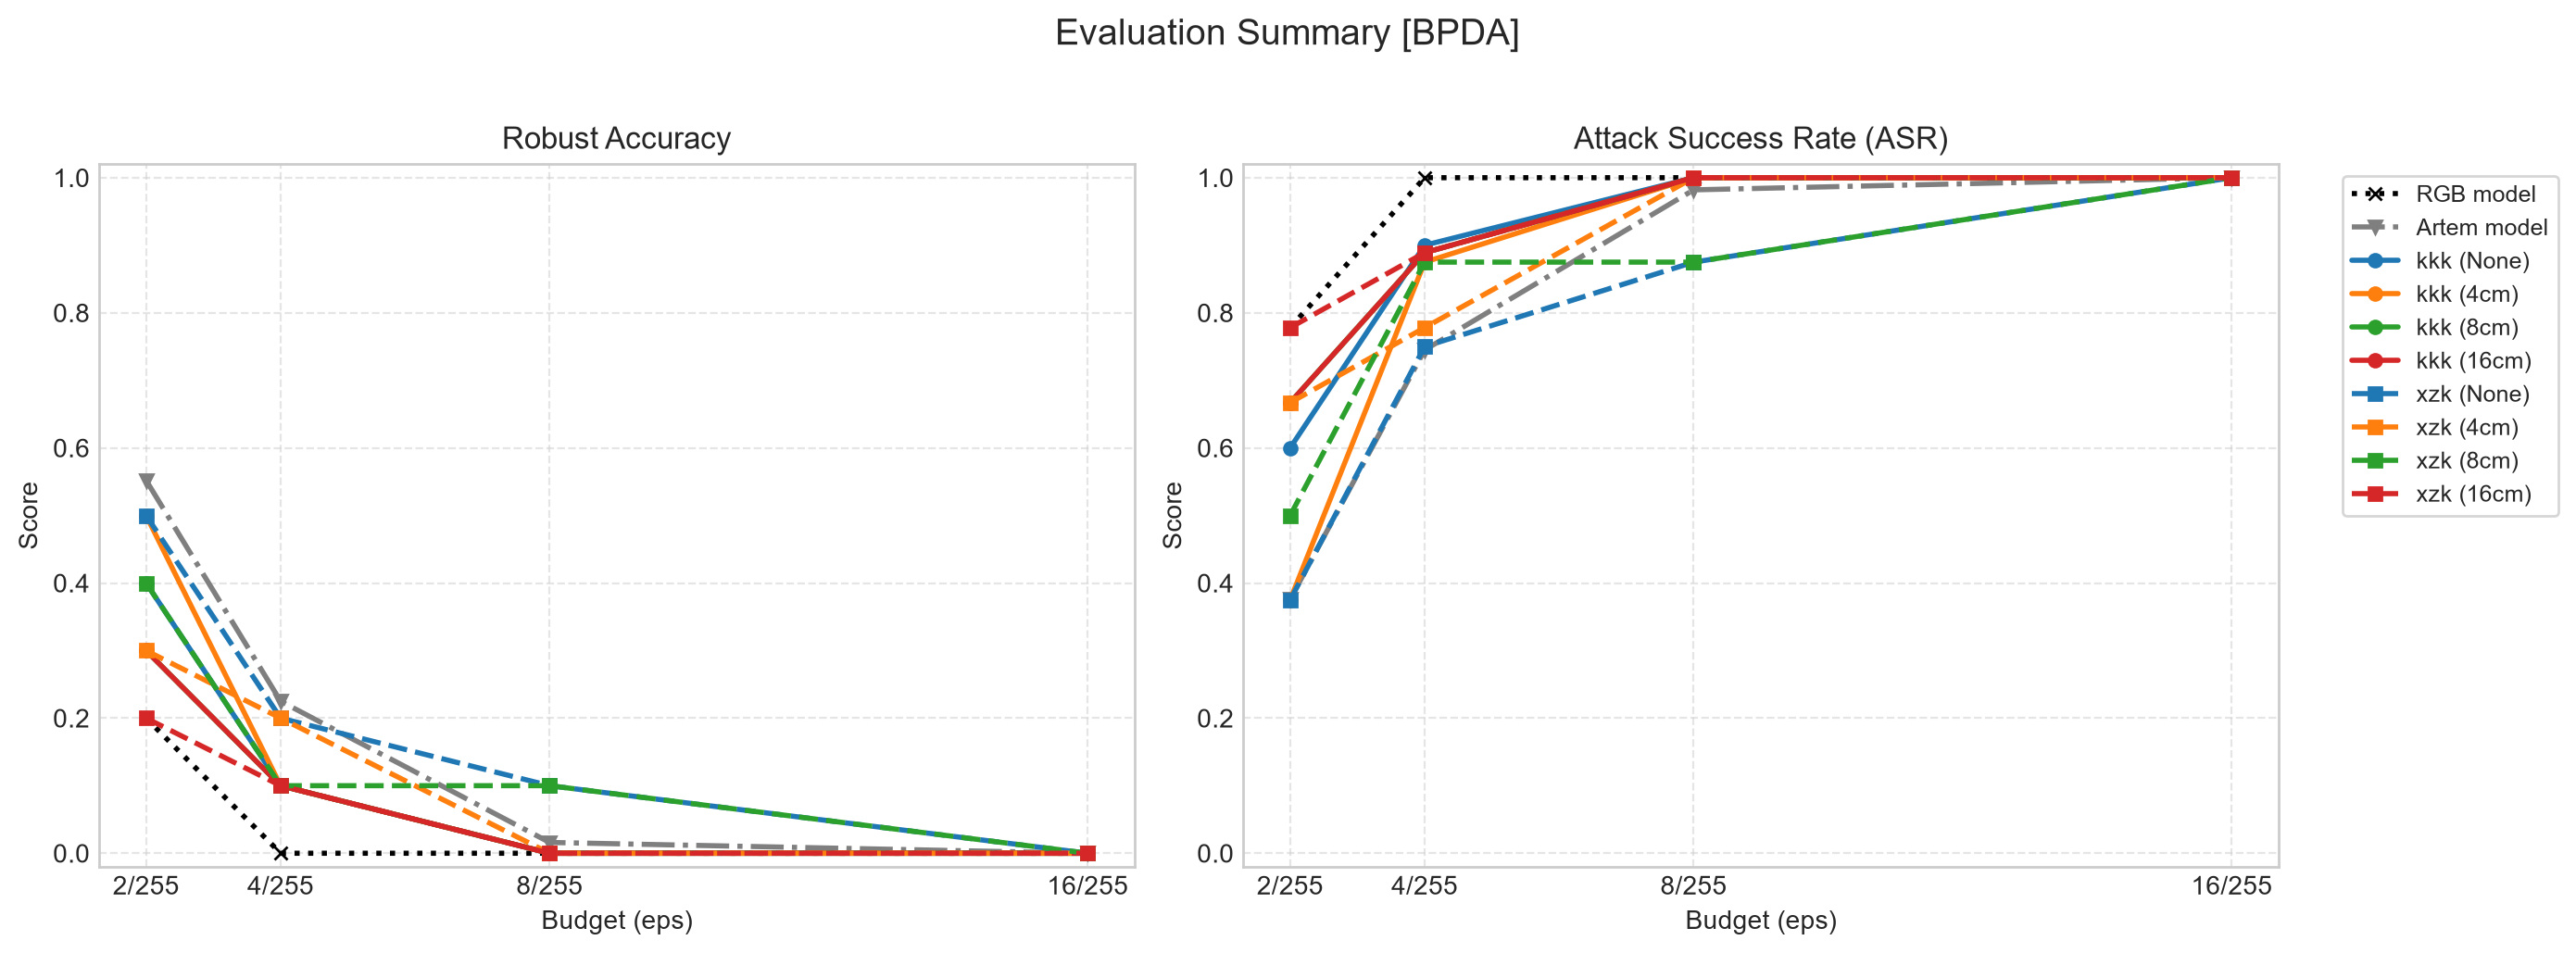

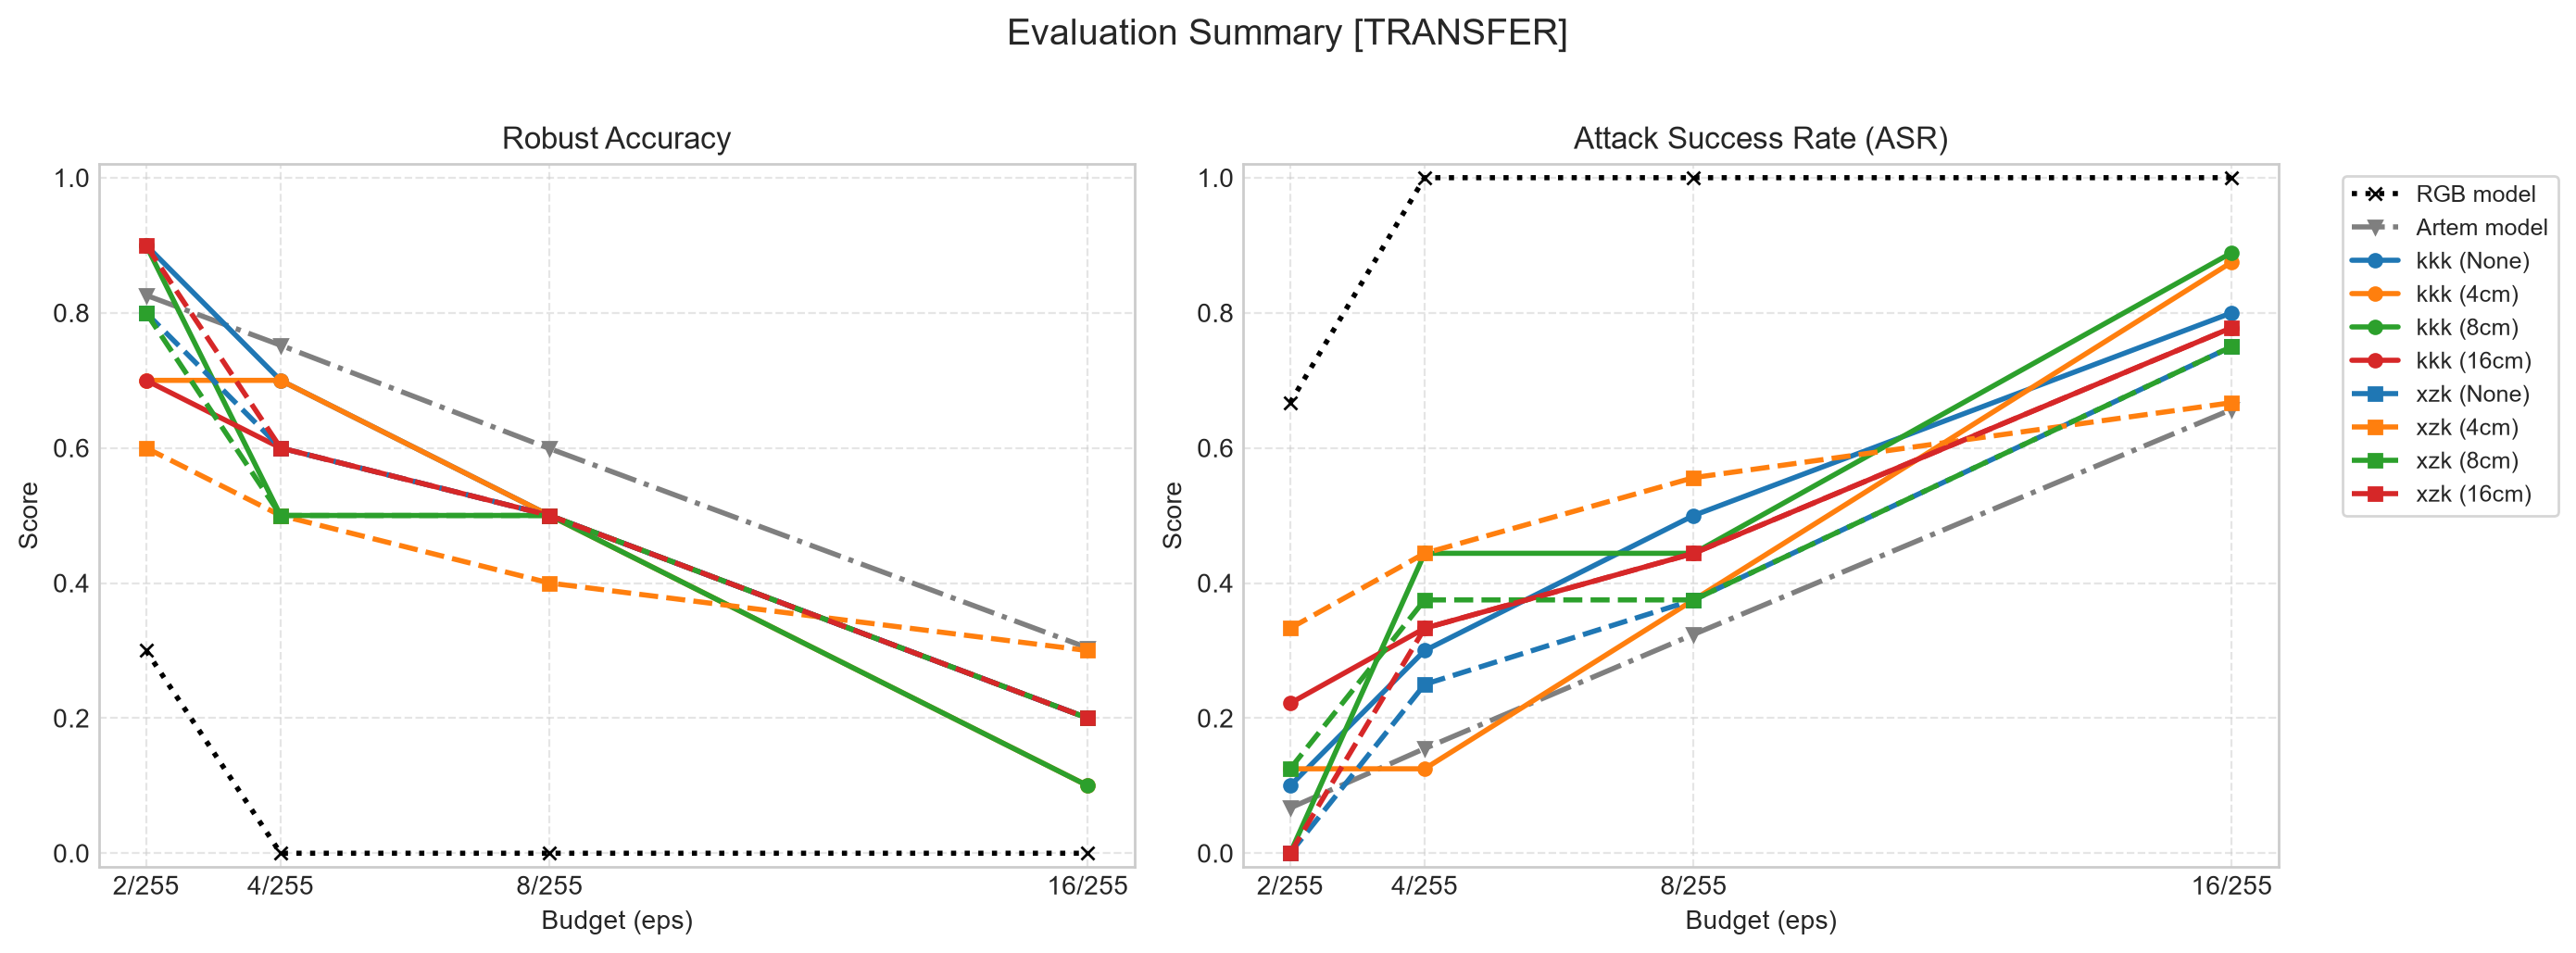

In [161]:
plots_dir = Path('../results/plots')
plots_dir.mkdir(parents=True, exist_ok=True)

df = df_comparison.copy()

df['approach'] = df['approach'].astype(str).str.strip()
df['approach'] = df['approach'].replace({'white-box': 'bpda'})

df['model'] = df['model'].astype(str).str.strip()

def parse_eps(val):
    if isinstance(val, str) and '/' in val:
        num, denom = val.split('/')
        return float(num) / float(denom)
    return float(val)

df['eps_val'] = df['eps'].apply(parse_eps)
df = df.sort_values('eps_val')

style_map = {
    'model_rgb': {'color': '#000000', 'linestyle': ':', 'marker': 'x', 'label': 'RGB model'},
    'mine': {'color': '#7f7f7f', 'linestyle': '-.', 'marker': 'v', 'label': 'Artem model'},
    'model_kkk_None': {'color': '#1f77b4', 'linestyle': '-', 'marker': 'o', 'label': 'kkk (None)'},
    'model_kkk_4cm': {'color': '#ff7f0e', 'linestyle': '-', 'marker': 'o', 'label': 'kkk (4cm)'},
    'model_kkk_8cm': {'color': '#2ca02c', 'linestyle': '-', 'marker': 'o', 'label': 'kkk (8cm)'},
    'model_kkk_16cm': {'color': '#d62728', 'linestyle': '-', 'marker': 'o', 'label': 'kkk (16cm)'},
    'model_xzk_None': {'color': '#1f77b4', 'linestyle': '--', 'marker': 's', 'label': 'xzk (None)'},
    'model_xzk_4cm': {'color': '#ff7f0e', 'linestyle': '--', 'marker': 's', 'label': 'xzk (4cm)'},
    'model_xzk_8cm': {'color': '#2ca02c', 'linestyle': '--', 'marker': 's', 'label': 'xzk (8cm)'},
    'model_xzk_16cm': {'color': '#d62728', 'linestyle': '--', 'marker': 's', 'label': 'xzk (16cm)'},
}

y_ticks = np.linspace(0.0, 1.0, 6)

def plot_summary_panel(approach_name):
    sub_df = df[df['approach'] == approach_name]
    if sub_df.empty:
        return

    eps_ticks = sorted(sub_df['eps_val'].unique())
    eps_labels = [f'{int(round(e * 255))}/255' for e in eps_ticks]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    metrics = [
        ('robust', 'Robust Accuracy', axes[0]),
        ('ASR', 'Attack Success Rate (ASR)', axes[1])
    ]

    for metric_col, title, ax in metrics:
        for model_name, style in style_map.items():
            m_data = sub_df[sub_df['model'] == model_name]
            if m_data.empty:
                continue

            ax.plot(
                m_data['eps_val'],
                m_data[metric_col],
                color=style['color'],
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=2,
                markersize=5,
                label=style['label']
            )

        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Budget (eps)', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_xticks(eps_ticks)
        ax.set_xticklabels(eps_labels)
        ax.set_yticks(y_ticks)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(True, linestyle='--', alpha=0.5)

    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=9)

    plt.suptitle(f'Evaluation Summary [{approach_name.upper()}]', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(plots_dir / f'{approach_name}_metrics_panel.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_summary_panel('bpda')
plot_summary_panel('transfer')